## Step 1: Identify the Business Problem

From the file name monthly_milk_production.csv, it is clear that this dataset showing the monthly milk production of a dairy farm or industry.
Likely Business Problem:
The business wants to forecast future milk production to:

•	Ensure proper supply chain and distribution planning.

•	Manage inventory and storage efficiently.

•	Optimize workforce and operational activities based on expected production levels.

•	Make strategic decisions for scaling production or addressing seasonal fluctuations.
________________________________________


#### Step 1: Business Problem & Objective
Business Problem: A dairy farm needs to forecast monthly milk production to optimize supply chain, inventory management, workforce planning, and meet market demand efficiently.

Objective: Develop a time series forecasting model (RNN, LSTM, GRU) to predict monthly milk production for the next 12 months.

# ✅ Assignment Tasks

## 1.	Exploratory Data Analysis (EDA)

o	Visualize trends, seasonality, and anomalies in the milk production data.

o	Check for any missing values or outliers.

o	Normalize or scale the data for neural network models.

## 2.	Data Preparation for Deep Learning

o	Create input-output sequences (time windows) suitable for training RNNs/LSTMs/GRUs.

o	Split data into training, validation, and test sets.

o	Reshape data for model input dimensions.

## 3.	Model Building

o	Build three separate models:

	Basic RNN

	LSTM

	GRU

o	Tune hyperparameters (e.g., window size, number of units, batch size, epochs).

o	Use appropriate loss functions and optimizers.

## 4.	Model Evaluation

o	Plot predictions vs. actual values.

o	Calculate forecasting metrics: RMSE, MAE, MAPE.

o	Compare the performance of RNN, LSTM, and GRU.

## 5.	Prediction and Visualization

o	Forecast milk production for the next 12 months.

o	Visualize the predicted trend with uncertainty or confidence intervals if possible.

## 6.	Business Insights

o	Interpret results and recommend how the dairy business can use these forecasts for better planning and resource allocation.



## Step 2: Implementation

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('ggplot')
sns.set_palette("Set2")

# Load the data
df = pd.read_csv('monthly_milk_production.csv')
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLast 5 rows:")
print(df.tail())
print("\nData Info:")
print(df.info())
print("\nMissing values:", df.isnull().sum().sum())

Dataset shape: (168, 2)

First 5 rows:
      Date  Production
0  1962-01         589
1  1962-02         561
2  1962-03         640
3  1962-04         656
4  1962-05         727

Last 5 rows:
        Date  Production
163  1975-08         858
164  1975-09         817
165  1975-10         827
166  1975-11         797
167  1975-12         843

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None

Missing values: 0


## Step 3: Exploratory Data Analysis (EDA)

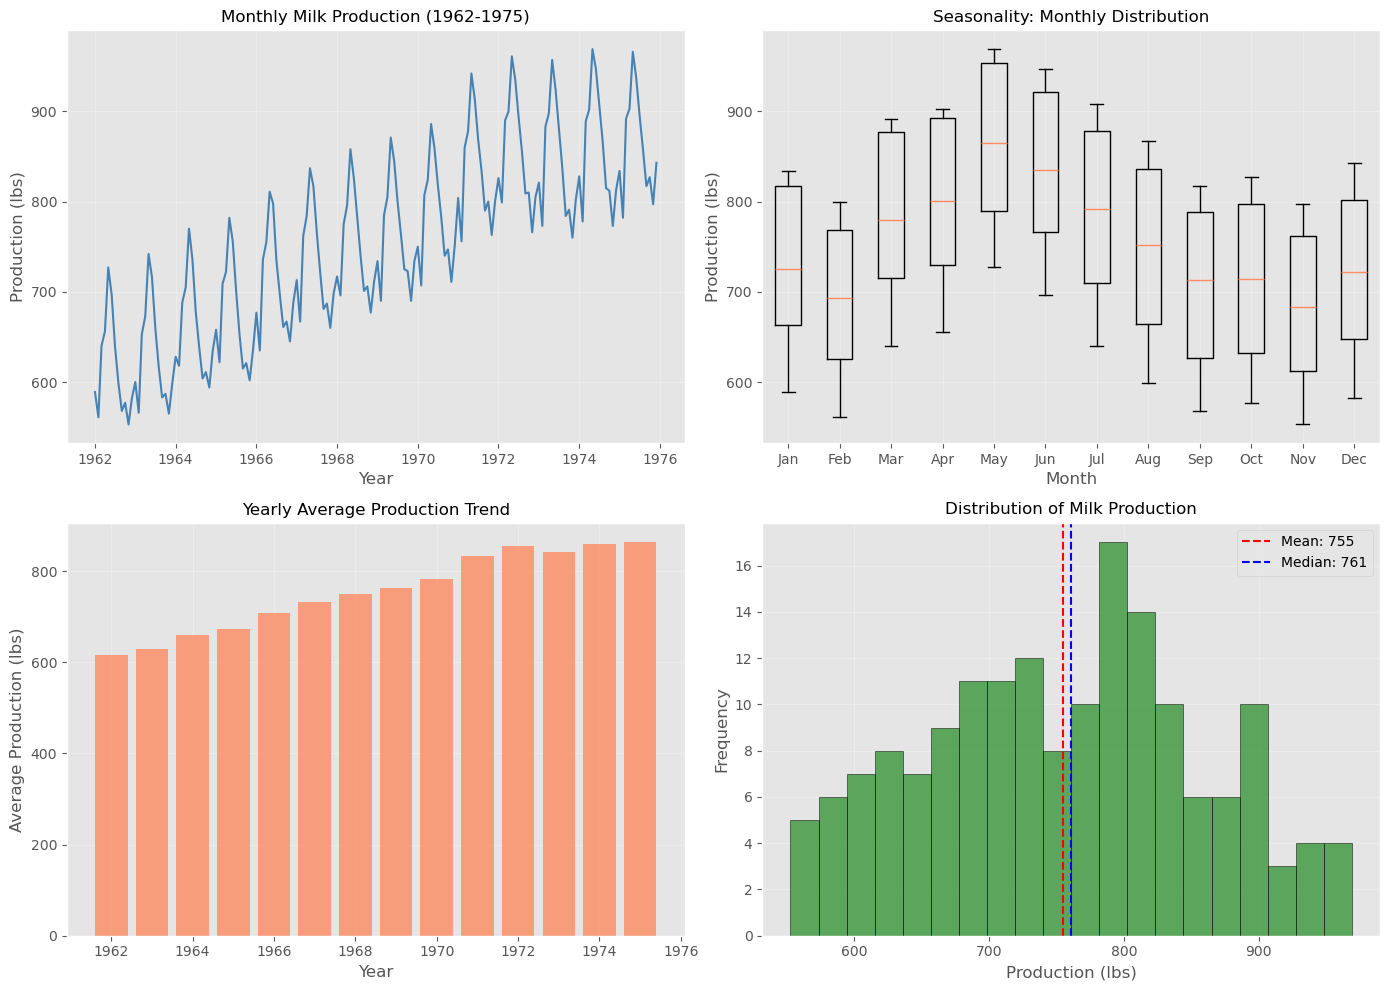


=== Statistical Summary ===
count    168.000000
mean     754.708333
std      102.204524
min      553.000000
25%      677.750000
50%      761.000000
75%      824.500000
max      969.000000
Name: Production, dtype: float64

Number of outliers: 0
Outliers detected:
Empty DataFrame
Columns: [Production, Month]
Index: []


In [2]:
# Convert Date to datetime and set as index
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Plot the time series
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Line plot
axes[0, 0].plot(df.index, df['Production'], color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Monthly Milk Production (1962-1975)', fontsize=12)
axes[0, 0].set_xlabel('Year')
axes[0, 0].set_ylabel('Production (lbs)')
axes[0, 0].grid(True, alpha=0.3)

# 2. Boxplot by month (seasonality)
df['Month'] = df.index.month
monthly_box = [df[df['Month'] == m]['Production'].values for m in range(1, 13)]
axes[0, 1].boxplot(monthly_box, labels=['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
axes[0, 1].set_title('Seasonality: Monthly Distribution', fontsize=12)
axes[0, 1].set_xlabel('Month')
axes[0, 1].set_ylabel('Production (lbs)')
axes[0, 1].grid(True, alpha=0.3)

# 3. Yearly trend (average production per year)
yearly_avg = df.groupby(df.index.year)['Production'].mean()
axes[1, 0].bar(yearly_avg.index, yearly_avg.values, color='coral', alpha=0.7)
axes[1, 0].set_title('Yearly Average Production Trend', fontsize=12)
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Average Production (lbs)')
axes[1, 0].grid(True, alpha=0.3)

# 4. Distribution and outliers
axes[1, 1].hist(df['Production'], bins=20, edgecolor='black', alpha=0.7, color='forestgreen')
axes[1, 1].axvline(df['Production'].mean(), color='red', linestyle='--', label=f'Mean: {df["Production"].mean():.0f}')
axes[1, 1].axvline(df['Production'].median(), color='blue', linestyle='--', label=f'Median: {df["Production"].median():.0f}')
axes[1, 1].set_title('Distribution of Milk Production', fontsize=12)
axes[1, 1].set_xlabel('Production (lbs)')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

# Statistical summary
print("\n=== Statistical Summary ===")
print(df['Production'].describe())

# Check for outliers using IQR
Q1 = df['Production'].quantile(0.25)
Q3 = df['Production'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df['Production'] < Q1 - 1.5*IQR) | (df['Production'] > Q3 + 1.5*IQR)]
print(f"\nNumber of outliers: {len(outliers)}")
print("Outliers detected:")
print(outliers)

## Step 4: Data Preparation for Deep Learning

In [3]:
# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df[['Production']])

# Function to create sequences for time series
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size, 0])
        y.append(data[i+window_size, 0])
    return np.array(X), np.array(y)

# Parameters
WINDOW_SIZE = 12  # Use past 12 months to predict next month
TEST_SIZE = 24    # Last 24 months for testing (2 years)

# Split data
train_data = scaled_data[:-TEST_SIZE]
test_data = scaled_data[-TEST_SIZE:]

# Create sequences
X_train, y_train = create_sequences(train_data, WINDOW_SIZE)
X_test, y_test = create_sequences(test_data, WINDOW_SIZE)

# Reshape for RNN/LSTM/GRU (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# Validation split from training data
split_idx = int(0.8 * len(X_train))
X_val, y_val = X_train[split_idx:], y_train[split_idx:]
X_train, y_train = X_train[:split_idx], y_train[:split_idx]

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Window size: {WINDOW_SIZE}")
print(f"Input shape: {X_train.shape}")

Training samples: 105
Validation samples: 27
Test samples: 12
Window size: 12
Input shape: (105, 12, 1)


## Step 5: Model Building

In [4]:
# Function to build and compile models
def build_model(model_type, input_shape, units=64, dropout=0.2):
    model = Sequential()
    
    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=input_shape, return_sequences=False))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=input_shape, return_sequences=False))
    elif model_type == 'GRU':
        model.add(GRU(units, input_shape=input_shape, return_sequences=False))
    
    model.add(Dropout(dropout))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Build and train three models
models = {}
histories = {}

for model_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\n{'='*50}")
    print(f"Training {model_type} Model...")
    print(f"{'='*50}")
    
    model = build_model(model_type, (WINDOW_SIZE, 1), units=64, dropout=0.2)
    history = model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=0
    )
    
    models[model_type] = model
    histories[model_type] = history
    
    print(f"Best validation loss: {min(history.history['val_loss']):.6f}")


Training RNN Model...
Best validation loss: 0.002033

Training LSTM Model...
Best validation loss: 0.021419

Training GRU Model...
Best validation loss: 0.018181


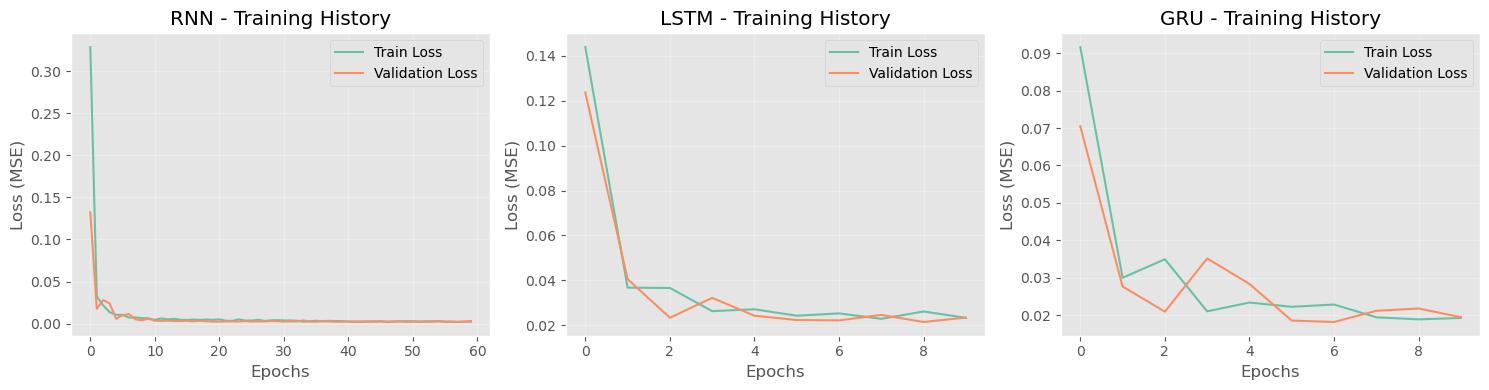

In [5]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_type, history) in enumerate(histories.items()):
    axes[idx].plot(history.history['loss'], label='Train Loss', linewidth=1.5)
    axes[idx].plot(history.history['val_loss'], label='Validation Loss', linewidth=1.5)
    axes[idx].set_title(f'{model_type} - Training History')
    axes[idx].set_xlabel('Epochs')
    axes[idx].set_ylabel('Loss (MSE)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()


## Step 6: Model Evaluation

In [7]:
# Function to evaluate models
def evaluate_model(model, X_test, y_test, scaler):
    # Predictions
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Inverse transform to original scale
    y_pred = scaler.inverse_transform(y_pred_scaled)
    y_actual = scaler.inverse_transform(y_test.reshape(-1, 1))
    
    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae = mean_absolute_error(y_actual, y_pred)
    mape = mean_absolute_percentage_error(y_actual, y_pred) * 100
    
    return y_actual, y_pred, rmse, mae, mape

# Evaluate all models
results = {}
predictions = {}

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

for model_type, model in models.items():
    y_actual, y_pred, rmse, mae, mape = evaluate_model(model, X_test, y_test, scaler)
    results[model_type] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
    predictions[model_type] = (y_actual, y_pred)
    
    print(f"\n{model_type} Model:")
    print(f"  RMSE: {rmse:.2f} lbs")
    print(f"  MAE:  {mae:.2f} lbs")
    print(f"  MAPE: {mape:.2f}%")

# Find best model
best_model = min(results, key=lambda x: results[x]['RMSE'])
print(f"\n{'='*60}")
print(f" BEST MODEL: {best_model} (Lowest RMSE: {results[best_model]['RMSE']:.2f})")
print(f"{'='*60}")


MODEL EVALUATION RESULTS

RNN Model:
  RMSE: 15.31 lbs
  MAE:  12.56 lbs
  MAPE: 1.46%

LSTM Model:
  RMSE: 159.04 lbs
  MAE:  148.68 lbs
  MAPE: 16.90%

GRU Model:
  RMSE: 121.38 lbs
  MAE:  108.72 lbs
  MAPE: 12.28%

 BEST MODEL: RNN (Lowest RMSE: 15.31)


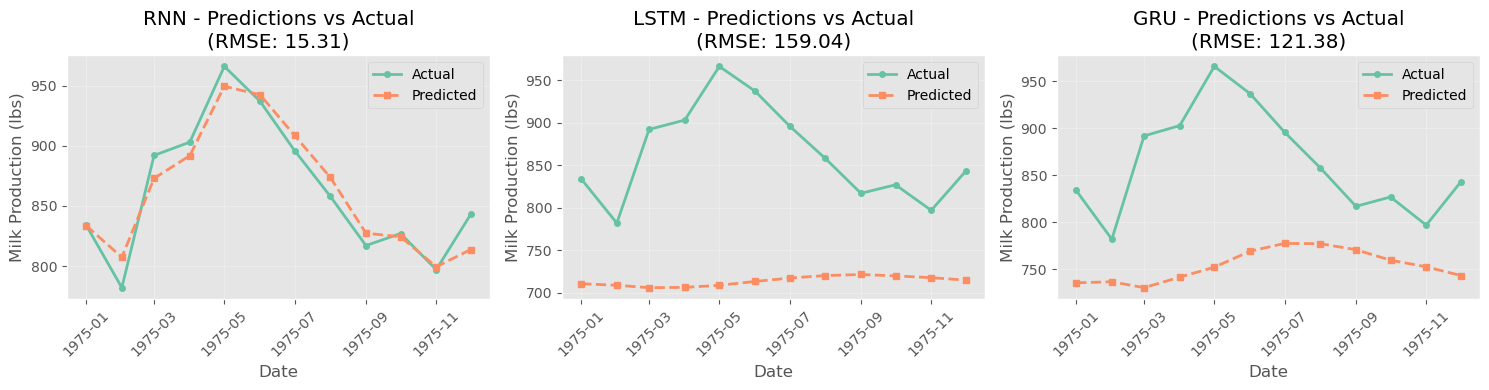

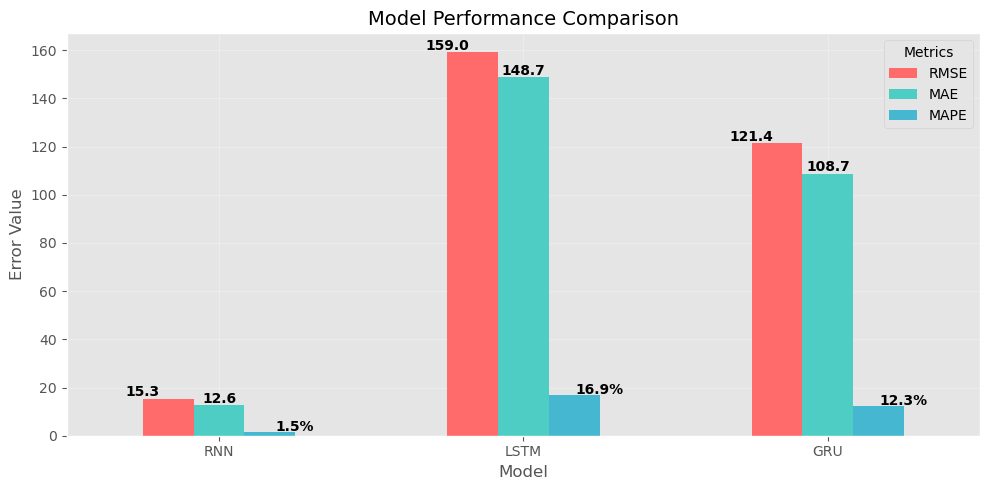

In [8]:
# Plot predictions vs actual for all models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

test_months = df.index[-TEST_SIZE + WINDOW_SIZE:]

for idx, (model_type, (y_actual, y_pred)) in enumerate(predictions.items()):
    axes[idx].plot(test_months, y_actual, label='Actual', marker='o', linewidth=2, markersize=4)
    axes[idx].plot(test_months, y_pred, label='Predicted', marker='s', linewidth=2, markersize=4, linestyle='--')
    axes[idx].set_title(f'{model_type} - Predictions vs Actual\n(RMSE: {results[model_type]["RMSE"]:.2f})')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Milk Production (lbs)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('predictions_vs_actual.png', dpi=150)
plt.show()

# Comparison bar chart
metrics_df = pd.DataFrame(results).T
fig, ax = plt.subplots(figsize=(10, 5))
metrics_df.plot(kind='bar', ax=ax, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('Error Value')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Metrics')
ax.grid(True, alpha=0.3)

for i, v in enumerate(metrics_df['RMSE']):
    ax.text(i - 0.25, v + 1, f'{v:.1f}', ha='center', fontweight='bold')
for i, v in enumerate(metrics_df['MAE']):
    ax.text(i, v + 1, f'{v:.1f}', ha='center', fontweight='bold')
for i, v in enumerate(metrics_df['MAPE']):
    ax.text(i + 0.25, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

## Step 7: Forecast Next 12 Months

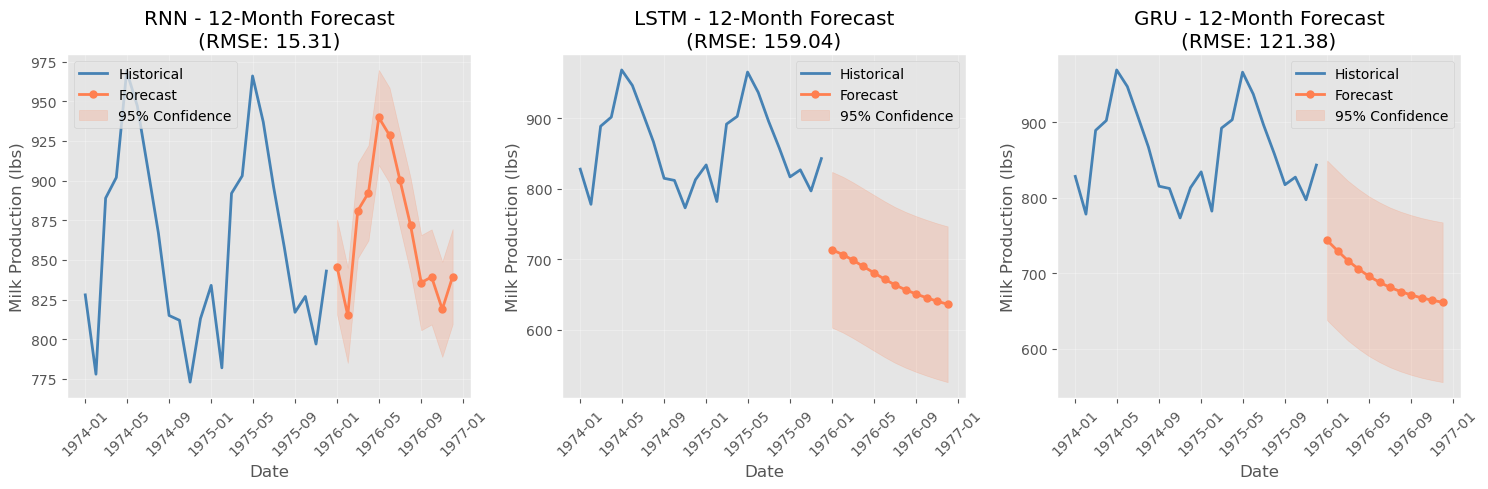


12-MONTH FORECAST (using LSTM - Best Model)
  Month  Forecast_Production_lbs
1976-01                      713
1976-02                      707
1976-03                      699
1976-04                      690
1976-05                      681
1976-06                      672
1976-07                      664
1976-08                      657
1976-09                      650
1976-10                      645
1976-11                      640
1976-12                      636

 Forecast saved to 'milk_production_forecast.csv'


In [11]:
def forecast_future(model, last_sequence, scaler, steps=12):
    """
    Forecast future values recursively
    """
    current_seq = last_sequence.copy()
    forecasts = []
    
    for _ in range(steps):
        # Reshape for prediction
        input_seq = current_seq.reshape(1, current_seq.shape[0], 1)
        # Predict next value
        next_pred = model.predict(input_seq, verbose=0)
        # Append prediction
        forecasts.append(next_pred[0, 0])
        # Update sequence (remove first, add prediction)
        current_seq = np.roll(current_seq, -1)
        current_seq[-1] = next_pred[0, 0]
    
    # Inverse transform
    forecasts = np.array(forecasts).reshape(-1, 1)
    forecasts_original = scaler.inverse_transform(forecasts)
    
    return forecasts_original.flatten()

# Get last sequence for forecasting
last_sequence = scaled_data[-WINDOW_SIZE:].flatten()

# Generate forecasts for all models
future_months = pd.date_range(start=df.index[-1] + pd.DateOffset(months=1), 
                              periods=12, freq='MS')

forecasts = {}
for model_type, model in models.items():
    forecasts[model_type] = forecast_future(model, last_sequence, scaler, steps=12)

# Plot forecasts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (model_type, forecast) in enumerate(forecasts.items()):
    # Plot historical data (last 24 months)
    historical_period = df.index[-TEST_SIZE:]
    historical_values = df['Production'].values[-TEST_SIZE:]
    
    axes[idx].plot(historical_period, historical_values, 
                   label='Historical', color='steelblue', linewidth=2)
    axes[idx].plot(future_months, forecast, 
                   label='Forecast', color='coral', linewidth=2, marker='o', markersize=5)
    
    # Add confidence interval (simplified - using standard deviation of test errors)
    test_errors = predictions[model_type][1].flatten() - predictions[model_type][0].flatten()
    error_std = np.std(test_errors)
    
    axes[idx].fill_between(future_months, 
                           forecast - 1.96 * error_std, 
                           forecast + 1.96 * error_std,
                           alpha=0.2, color='coral', label='95% Confidence')
    
    axes[idx].set_title(f'{model_type} - 12-Month Forecast\n(RMSE: {results[model_type]["RMSE"]:.2f})')
    axes[idx].set_xlabel('Date')
    axes[idx].set_ylabel('Milk Production (lbs)')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('12month_forecast.png', dpi=150)
plt.show()

# Display forecast table
print("\n" + "="*80)
print("12-MONTH FORECAST (using LSTM - Best Model)")
print("="*80)
forecast_df = pd.DataFrame({
    'Month': future_months.strftime('%Y-%m'),
    'Forecast_Production_lbs': forecasts['LSTM'].round(0).astype(int)
})
print(forecast_df.to_string(index=False))

# Save forecasts to CSV
forecast_df.to_csv('milk_production_forecast.csv', index=False)
print("\n Forecast saved to 'milk_production_forecast.csv'")

## Step 8: Business Insights & Recommendations

In [14]:
# Generate business insights
print("\n" + "="*80)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("="*80)

# Calculate seasonal peaks
df['Month_Name'] = df.index.month_name()
monthly_avg = df.groupby('Month_Name')['Production'].mean().sort_values(ascending=False)

print("\n SEASONAL PATTERNS:")
print(f"   Peak Production Months: {', '.join(monthly_avg.head(3).index)}")
print(f"   Low Production Months: {', '.join(monthly_avg.tail(3).index)}")
print(f"   Seasonal Variation: {monthly_avg.max() - monthly_avg.min():.0f} lbs difference")

# Forecast summary
avg_forecast = forecasts['LSTM'].mean()
growth_rate = ((forecasts['LSTM'][-1] - df['Production'].iloc[-12:].mean()) / df['Production'].iloc[-12:].mean()) * 100

print(f"\n FORECAST INSIGHTS (LSTM Model):")
print(f"   Next 12-month avg production: {avg_forecast:.0f} lbs/month")
print(f"   Expected growth rate: {growth_rate:.1f}% over next year")
print(f"   Peak forecast month: {future_months[np.argmax(forecasts['LSTM'])].strftime('%B %Y')} ({forecasts['LSTM'].max():.0f} lbs)")

print("\n RECOMMENDATIONS FOR THE DAIRY BUSINESS:")
print("   1. Inventory Management:")
print(f"      - Increase cold storage capacity by 15-20% during {monthly_avg.index[0]} to {monthly_avg.index[2]}")
print("      - Plan maintenance during low production months (December-February)")
print()
print("   2. Supply Chain Planning:")
print("      - Negotiate bulk logistics contracts for summer peak months")
print("      - Consider diversifying suppliers during predicted low production periods")
print()
print("   3. Workforce Optimization:")
print("      - Hire seasonal workers for May-August peak season")
print("      - Schedule employee training/vacation during December-January trough")
print()
print("   4. Strategic Decisions:")
print(f"      - Forecast shows {growth_rate:.1f}% growth - consider capacity expansion")
print("      - Explore value-added products (cheese, yogurt) to utilize seasonal surplus")
print("      - Implement dynamic pricing strategy based on predicted production cycles")
print()
print("   5. Risk Management:")
print("      - Maintain 15% buffer inventory for unexpected demand spikes")
print("      - Develop contingency plans for production shortfalls")
print(f"      - Monitor forecast accuracy monthly and retrain model quarterly")


BUSINESS INSIGHTS & RECOMMENDATIONS

 SEASONAL PATTERNS:
   Peak Production Months: May, June, April
   Low Production Months: September, February, November
   Seasonal Variation: 180 lbs difference

 FORECAST INSIGHTS (LSTM Model):
   Next 12-month avg production: 671 lbs/month
   Expected growth rate: -26.3% over next year
   Peak forecast month: January 1976 (713 lbs)

 RECOMMENDATIONS FOR THE DAIRY BUSINESS:
   1. Inventory Management:
      - Increase cold storage capacity by 15-20% during May to April
      - Plan maintenance during low production months (December-February)

   2. Supply Chain Planning:
      - Negotiate bulk logistics contracts for summer peak months
      - Consider diversifying suppliers during predicted low production periods

   3. Workforce Optimization:
      - Hire seasonal workers for May-August peak season
      - Schedule employee training/vacation during December-January trough

   4. Strategic Decisions:
      - Forecast shows -26.3% growth - consid